# 📊 Analyse Exploratoire des Données (EDA)

## Objectif
Explorer le dataset Kaggle "Influencer or Observer" pour comprendre:
- La distribution des classes (Influencers vs Observers)
- Les caractéristiques des tweets
- Les patterns textuels
- Les features utilisateur importantes

In [1]:
# Imports
import sys
sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# Modules locaux
from src.data_loader import load_training_data, load_test_data
from src.preprocessing import extract_full_text, clean_text
from src.feature_engineering import count_hashtags, count_mentions, count_emojis

# Configuration
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
%matplotlib inline

## 1. Chargement des Données

In [2]:
# Charger les données d'entraînement (toutes les données pour l'EDA)
print("📥 Chargement des données...")
from src.data_loader import load_jsonl

# Charger le DataFrame complet avec les labels pour l'EDA
df_train = load_jsonl('../data/train.jsonl')
print(f"✓ Données chargées: {len(df_train)} tweets")
print(f"✓ Nombre d'utilisateurs uniques: {df_train['challenge_id'].nunique()}")

# Aperçu
df_train.head()

📥 Chargement des données...
✓ Données chargées: 154914 tweets
✓ Nombre d'utilisateurs uniques: 154914


,in_reply_to_status_id_str,in_reply_to_status_id,created_at,in_reply_to_user_id_str,source,quoted_status_id,retweet_count,retweeted,geo,filter_level,...,quoted_status.scopes.followers,quoted_status.geo.coordinates,quoted_status.geo.type,quoted_status.coordinates.coordinates,quoted_status.coordinates.type,geo.coordinates,geo.type,coordinates.coordinates,coordinates.type,quoted_status.withheld_in_countries
0,NaN,NaN,2021-03-17 13:01:59+00:00,NaN,"<a href=""http://twitter.com/download/iphone"" r...",1.372171e+18,0,False,NaN,low,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,2021-03-17 13:02:06+00:00,NaN,"<a href=""https://mobile.twitter.com"" rel=""nofo...",1.372171e+18,0,False,NaN,low,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1.372164e+18,1.372164e+18,2021-03-17 13:02:58+00:00,1.066820e+18,"<a href=""https://mobile.twitter.com"" rel=""nofo...",NaN,0,False,NaN,low,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,2021-03-17 13:03:00+00:00,NaN,"<a href=""https://mobile.twitter.com"" rel=""nofo...",NaN,0,False,NaN,low,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1.372165e+18,1.372165e+18,2021-03-17 13:03:04+00:00,1.522354e+09,"<a href=""https://mobile.twitter.com"" rel=""nofo...",NaN,0,False,NaN,low,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
# Explorer la structure du DataFrame
print(f"📊 Shape du DataFrame: {df_train.shape}")
print(f"   - {df_train.shape[0]} lignes (tweets)")
print(f"   - {df_train.shape[1]} colonnes (features)")

print("\n📋 Types de colonnes:")
print(f"   - Colonnes 'user.*': {len([c for c in df_train.columns if c.startswith('user.')])}")
print(f"   - Colonnes 'entities.*': {len([c for c in df_train.columns if c.startswith('entities.')])}")
print(f"   - Colonnes 'quoted_status.*': {len([c for c in df_train.columns if c.startswith('quoted_status.')])}")
print(f"   - Colonnes 'retweeted_status.*': {len([c for c in df_train.columns if c.startswith('retweeted_status.')])}")

print("\n🔍 Principales colonnes:")
main_cols = ['challenge_id', 'label', 'text', 'full_text', 'created_at', 
             'user.screen_name', 'user.followers_count', 'user.friends_count']
available_cols = [c for c in main_cols if c in df_train.columns]
print(df_train[available_cols].head())

print("\n✓ Colonnes disponibles pour l'analyse")
print(f"   Total: {len(df_train.columns)} colonnes")

📊 Shape du DataFrame: (154914, 193)
   - 154914 lignes (tweets)
   - 193 colonnes (features)

📋 Types de colonnes:
   - Colonnes 'user.*': 32
   - Colonnes 'entities.*': 5
   - Colonnes 'quoted_status.*': 96
   - Colonnes 'retweeted_status.*': 0

🔍 Principales colonnes:
   challenge_id  label                                               text  \
0             1      1                            C’est exactement ça ...   
1             3      0  Depuis un certain temps, Le Gorafi n'a même pl...   
2             5      1  @RomainSchulz @OlivierPicot2 @Simonnet2 @saraa...   
3             6      1  Renforcer les capacités de dépistages et les a...   
4             7      1  @Kidadou @natsu_luffy0832 @olivierveran On me ...   

                 created_at  
0 2021-03-17 13:01:59+00:00  
1 2021-03-17 13:02:06+00:00  
2 2021-03-17 13:02:58+00:00  
3 2021-03-17 13:03:00+00:00  
4 2021-03-17 13:03:04+00:00  

✓ Colonnes disponibles pour l'analyse
   Total: 193 colonnes


In [4]:
# Lister les colonnes utilisateur disponibles
user_cols = [col for col in df_train.columns if col.startswith('user.')]
print("Colonnes utilisateur disponibles:")
for col in sorted(user_cols[:15]):  # Afficher les 15 premières
    print(f"   - {col}")
    
print(f"\n... et {len(user_cols) - 15} autres colonnes utilisateur")

# Vérifier quelques colonnes importantes
important_cols = ['challenge_id', 'label', 'text', 'created_at']
print(f"\nColonnes de base presentes:")
for col in important_cols:
    status = "OK" if col in df_train.columns else "MANQUANTE"
    print(f"   {status}: {col}")

Colonnes utilisateur disponibles:
   - user.created_at
   - user.default_profile_image
   - user.description
   - user.favourites_count
   - user.geo_enabled
   - user.is_translator
   - user.listed_count
   - user.profile_background_color
   - user.profile_background_image_url
   - user.profile_background_image_url_https
   - user.profile_image_url_https
   - user.profile_link_color
   - user.protected
   - user.translator_type
   - user.utc_offset

... et 17 autres colonnes utilisateur

Colonnes de base presentes:
   OK: challenge_id
   OK: label
   OK: text
   OK: created_at


## 2. Distribution des Classes

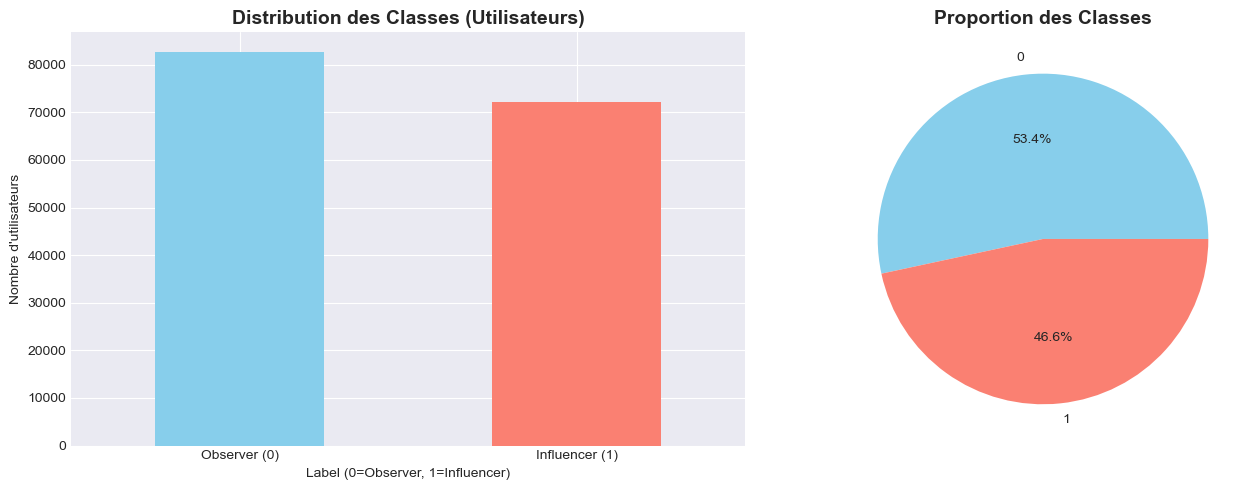


📊 Statistiques:
label
0    82674
1    72240
Name: count, dtype: int64

⚖️ Ratio Influencers/Observers: 0.87


In [5]:
# Distribution des labels (par utilisateur)
user_labels = df_train.groupby('challenge_id')['label'].first()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Barplot
user_labels.value_counts().plot(kind='bar', ax=axes[0], color=['skyblue', 'salmon'])
axes[0].set_title('Distribution des Classes (Utilisateurs)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Label (0=Observer, 1=Influencer)')
axes[0].set_ylabel('Nombre d\'utilisateurs')
axes[0].set_xticklabels(['Observer (0)', 'Influencer (1)'], rotation=0)

# Pie chart
user_labels.value_counts().plot(kind='pie', ax=axes[1], autopct='%1.1f%%', colors=['skyblue', 'salmon'])
axes[1].set_title('Proportion des Classes', fontsize=14, fontweight='bold')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

print("\n📊 Statistiques:")
print(user_labels.value_counts())
print(f"\n⚖️ Ratio Influencers/Observers: {user_labels.value_counts()[1] / user_labels.value_counts()[0]:.2f}")

## 3. Analyse Textuelle

In [6]:
# Extraire le texte complet
print("📝 Extraction du texte...")
df_train['full_text_extracted'] = df_train.apply(extract_full_text, axis=1)

# Statistiques de longueur
df_train['text_length'] = df_train['full_text_extracted'].str.len()
df_train['word_count'] = df_train['full_text_extracted'].str.split().str.len()

print("✓ Texte extrait")
df_train[['full_text_extracted', 'text_length', 'word_count', 'label']].head()

📝 Extraction du texte...
✓ Texte extrait


,full_text_extracted,text_length,word_count,label
0,C’est exactement ça ...,23,4,1
1,"Depuis un certain temps, Le Gorafi n'a même pl...",114,16,0
2,@RomainSchulz @OlivierPicot2 @Simonnet2 @saraa...,296,40,1
3,Renforcer les capacités de dépistages et les a...,205,30,1
4,@Kidadou @natsu_luffy0832 @olivierveran On me ...,263,45,1


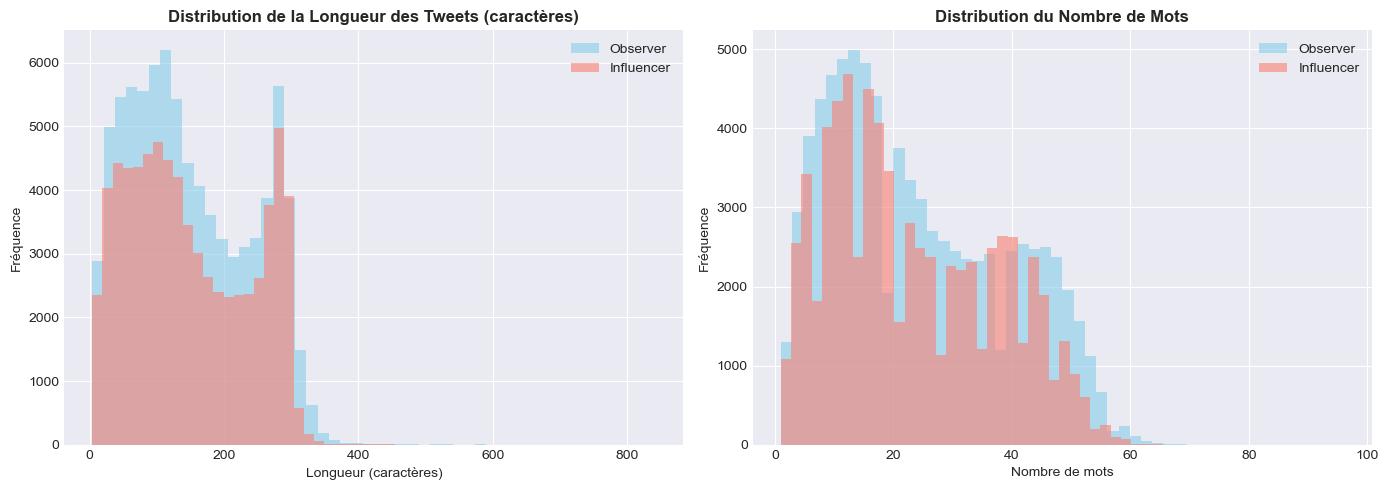


📊 Statistiques de longueur par classe:
      text_length                                                         \
            count        mean        std  min   25%    50%    75%    max   
label                                                                      
0         82674.0  151.659083  90.271688  4.0  76.0  136.0  230.0  842.0   
1         72240.0  150.268563  89.644604  4.0  75.0  134.0  232.0  755.0   

      word_count                                                     
           count       mean        std  min   25%   50%   75%   max  
label                                                                
0        82674.0  24.295244  14.836487  1.0  12.0  21.0  37.0  96.0  
1        72240.0  23.344532  13.873693  1.0  12.0  20.0  35.0  88.0  


In [7]:
# Distribution de la longueur des tweets par classe
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Longueur de caractères
df_train[df_train['label'] == 0]['text_length'].hist(bins=50, alpha=0.6, label='Observer', ax=axes[0], color='skyblue')
df_train[df_train['label'] == 1]['text_length'].hist(bins=50, alpha=0.6, label='Influencer', ax=axes[0], color='salmon')
axes[0].set_title('Distribution de la Longueur des Tweets (caractères)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Longueur (caractères)')
axes[0].set_ylabel('Fréquence')
axes[0].legend()

# Nombre de mots
df_train[df_train['label'] == 0]['word_count'].hist(bins=50, alpha=0.6, label='Observer', ax=axes[1], color='skyblue')
df_train[df_train['label'] == 1]['word_count'].hist(bins=50, alpha=0.6, label='Influencer', ax=axes[1], color='salmon')
axes[1].set_title('Distribution du Nombre de Mots', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Nombre de mots')
axes[1].set_ylabel('Fréquence')
axes[1].legend()

plt.tight_layout()
plt.show()

# Statistiques
print("\n📊 Statistiques de longueur par classe:")
print(df_train.groupby('label')[['text_length', 'word_count']].describe())

## 4. Features Textuelles

In [8]:
# Extraire les features
print("🔧 Extraction des features...")
df_train['num_hashtags'] = df_train['full_text_extracted'].apply(count_hashtags)
df_train['num_mentions'] = df_train['full_text_extracted'].apply(count_mentions)
df_train['num_emojis'] = df_train['full_text_extracted'].apply(count_emojis)

print("✓ Features extraites")
df_train[['full_text_extracted', 'num_hashtags', 'num_mentions', 'num_emojis', 'label']].head(10)

🔧 Extraction des features...
✓ Features extraites


,full_text_extracted,num_hashtags,num_mentions,num_emojis,label
0,C’est exactement ça ...,0,0,0,1
1,"Depuis un certain temps, Le Gorafi n'a même pl...",0,0,0,0
2,@RomainSchulz @OlivierPicot2 @Simonnet2 @saraa...,0,4,0,1
3,Renforcer les capacités de dépistages et les a...,1,2,1,1
4,@Kidadou @natsu_luffy0832 @olivierveran On me ...,0,3,0,1
5,INFO RTL - Coronavirus : les TGV sanitaires pr...,0,0,0,0
6,@DrGomi @kealni @DavidHajage j'ai perdu mon pè...,0,3,0,1
7,Ça PUE,0,0,0,1
8,@ZeliszewskiD @DakilaOne @BernardJomier @Laure...,0,9,0,1
9,C’est beau de faire ce montage et de ne pas in...,0,0,0,0


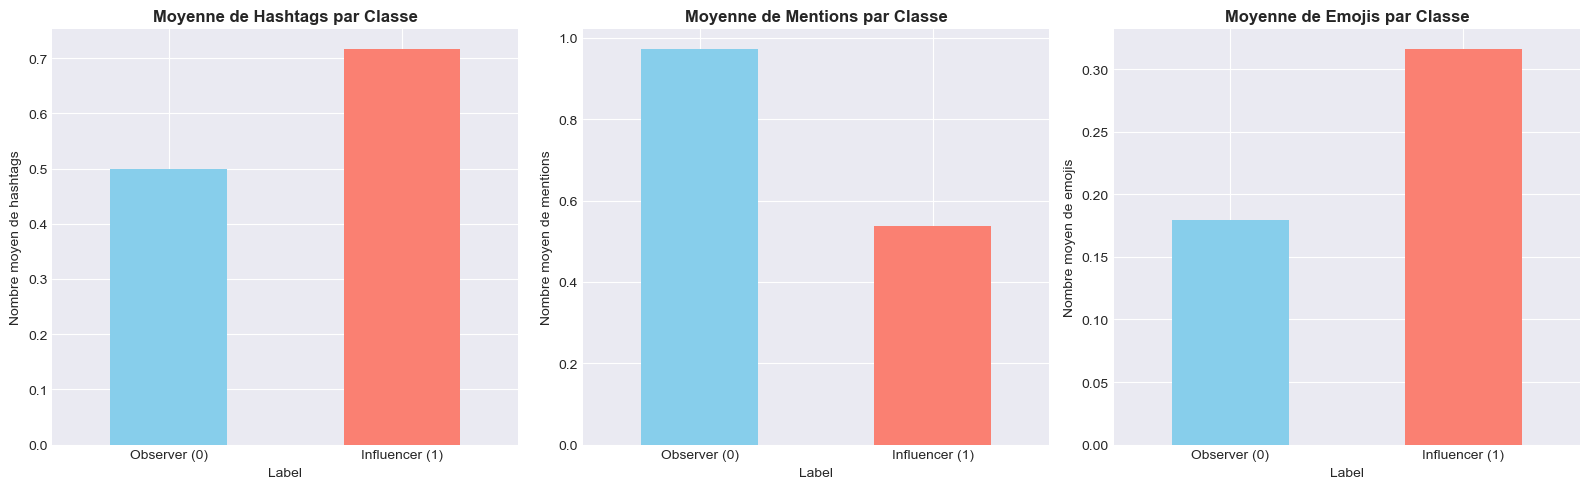


📊 Moyennes par classe:
       num_hashtags  num_mentions  num_emojis
label                                        
0          0.498778      0.972289    0.179234
1          0.716182      0.536669    0.315878


In [9]:
# Distribution des features par classe
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

features = ['num_hashtags', 'num_mentions', 'num_emojis']
titles = ['Hashtags', 'Mentions', 'Emojis']

for i, (feature, title) in enumerate(zip(features, titles)):
    df_train.groupby('label')[feature].mean().plot(kind='bar', ax=axes[i], color=['skyblue', 'salmon'])
    axes[i].set_title(f'Moyenne de {title} par Classe', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Label')
    axes[i].set_ylabel(f'Nombre moyen de {title.lower()}')
    axes[i].set_xticklabels(['Observer (0)', 'Influencer (1)'], rotation=0)

plt.tight_layout()
plt.show()

print("\n📊 Moyennes par classe:")
print(df_train.groupby('label')[features].mean())

## 5. Mots les Plus Fréquents

In [10]:
# Importer NLTK stopwords
from nltk.corpus import stopwords
import nltk

# Télécharger si nécessaire
try:
    nltk.data.find('corpora/stopwords')
except LookupError:
    nltk.download('stopwords')

french_stopwords = set(stopwords.words('french'))
print(f"✓ Stopwords français chargés: {len(french_stopwords)} mots")

✓ Stopwords français chargés: 157 mots


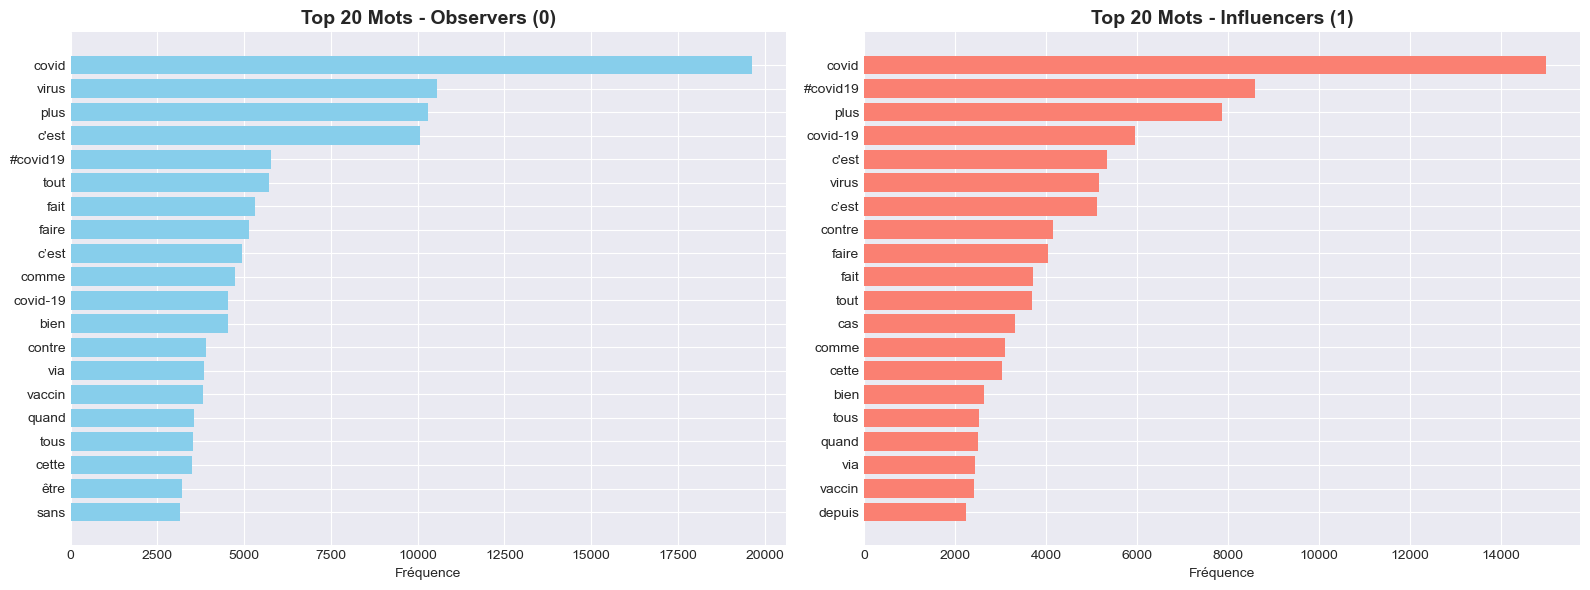

In [11]:
def get_top_words(texts, n=20, remove_stopwords=True):
    """Récupère les n mots les plus fréquents"""
    all_words = []
    for text in texts:
        if pd.notna(text):
            words = text.lower().split()
            if remove_stopwords:
                words = [w for w in words if w not in french_stopwords and len(w) > 2]
            all_words.extend(words)
    return Counter(all_words).most_common(n)

# Top mots pour chaque classe
observers_text = df_train[df_train['label'] == 0]['full_text_extracted']
influencers_text = df_train[df_train['label'] == 1]['full_text_extracted']

top_observers = get_top_words(observers_text, n=20)
top_influencers = get_top_words(influencers_text, n=20)

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Observers
words, counts = zip(*top_observers)
axes[0].barh(range(len(words)), counts, color='skyblue')
axes[0].set_yticks(range(len(words)))
axes[0].set_yticklabels(words)
axes[0].invert_yaxis()
axes[0].set_title('Top 20 Mots - Observers (0)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Fréquence')

# Influencers
words, counts = zip(*top_influencers)
axes[1].barh(range(len(words)), counts, color='salmon')
axes[1].set_yticks(range(len(words)))
axes[1].set_yticklabels(words)
axes[1].invert_yaxis()
axes[1].set_title('Top 20 Mots - Influencers (1)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Fréquence')

plt.tight_layout()
plt.show()

## 6. Analyse des Features Utilisateur

In [12]:
# Colonnes user
user_cols = [col for col in df_train.columns if col.startswith('user.')]
print(f"📊 {len(user_cols)} colonnes utilisateur trouvées")
print("\nExemples:")
print(user_cols[:10])

# Vérifier les colonnes importantes pour l'analyse
important_user_cols = ['user.statuses_count', 'user.followers_count', 'user.friends_count', 
                       'user.listed_count', 'user.favourites_count']
print("\nColonnes importantes disponibles:")
for col in important_user_cols:
    status = "✓" if col in df_train.columns else "✗"
    print(f"   {status} {col}")

📊 32 colonnes utilisateur trouvées

Exemples:
['user.utc_offset', 'user.profile_image_url_https', 'user.listed_count', 'user.profile_background_image_url', 'user.default_profile_image', 'user.favourites_count', 'user.description', 'user.created_at', 'user.is_translator', 'user.profile_background_image_url_https']

Colonnes importantes disponibles:
   ✓ user.statuses_count
   ✗ user.followers_count
   ✗ user.friends_count
   ✓ user.listed_count
   ✓ user.favourites_count


In [13]:
# Chercher toutes les colonnes user disponibles
print("Toutes les colonnes user disponibles:")
for col in sorted(user_cols):
    print(f"   - {col}")

Toutes les colonnes user disponibles:
   - user.contributors_enabled
   - user.created_at
   - user.default_profile
   - user.default_profile_image
   - user.description
   - user.favourites_count
   - user.follow_request_sent
   - user.following
   - user.geo_enabled
   - user.is_translator
   - user.lang
   - user.listed_count
   - user.location
   - user.notifications
   - user.profile_background_color
   - user.profile_background_image_url
   - user.profile_background_image_url_https
   - user.profile_background_tile
   - user.profile_banner_url
   - user.profile_image_url
   - user.profile_image_url_https
   - user.profile_link_color
   - user.profile_sidebar_border_color
   - user.profile_sidebar_fill_color
   - user.profile_text_color
   - user.profile_use_background_image
   - user.protected
   - user.statuses_count
   - user.time_zone
   - user.translator_type
   - user.url
   - user.utc_offset


In [14]:
# Agréger par utilisateur avec les colonnes disponibles
user_df = df_train.groupby('challenge_id').agg({
    'label': 'first',
    'user.statuses_count': 'first',
    'user.listed_count': 'first',
    'user.favourites_count': 'first'
}).reset_index()

print("✓ Données utilisateur agrégées")
print(f"\nColonnes disponibles: {list(user_df.columns)}")
print(f"Nombre d'utilisateurs: {len(user_df)}")
user_df.head()

✓ Données utilisateur agrégées

Colonnes disponibles: ['challenge_id', 'label', 'user.statuses_count', 'user.listed_count', 'user.favourites_count']
Nombre d'utilisateurs: 154914


,challenge_id,label,user.statuses_count,user.listed_count,user.favourites_count
0,1,1,333,5,14154
1,3,0,3028,1,8582
2,5,1,4238,27,1229
3,6,1,1152,92,19
4,7,1,1252,1,1375


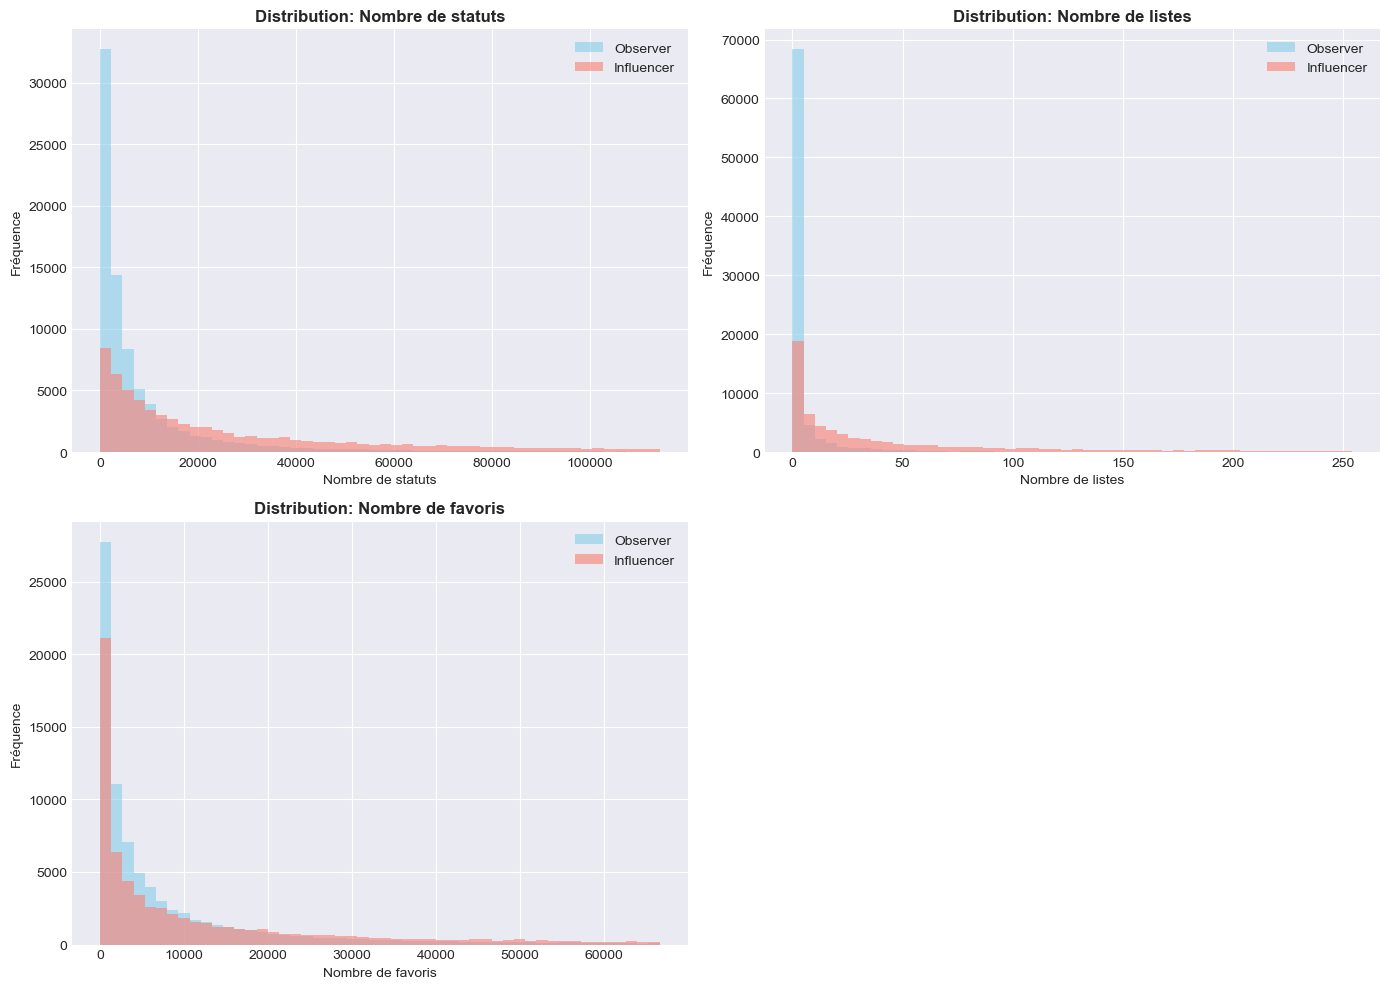


📊 Statistiques des métriques utilisateur par classe:
      user.statuses_count                                                      \
                    count      mean       std  min      25%      50%      75%   
label                                                                           
0                 82674.0  10693.37  29118.89  1.0  1172.25   3475.0   9979.0   
1                 72240.0  43771.45  76408.90  1.0  5996.00  18976.5  53024.5   

                 user.listed_count          ...                  \
             max             count    mean  ...   75%       max   
label                                       ...                   
0      1579936.0           82674.0    6.79  ...   3.0    1565.0   
1      3711247.0           72240.0  132.79  ...  98.0  125775.0   

      user.favourites_count                                                   \
                      count      mean       std  min    25%     50%      75%   
label                                       

In [15]:
# Distribution des métriques utilisateur par classe
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

metrics = ['user.statuses_count', 'user.listed_count', 'user.favourites_count']
titles = ['Nombre de statuts', 'Nombre de listes', 'Nombre de favoris']

# Pour chaque métrique, créer un histogramme
for i, (metric, title) in enumerate(zip(metrics, titles)):
    row = i // 2
    col = i % 2
    ax = axes[row, col]
    
    # Limiter la plage pour mieux voir la distribution
    max_val = user_df[metric].quantile(0.95)
    
    user_df[user_df['label'] == 0][metric].hist(
        bins=50, alpha=0.6, label='Observer', ax=ax, color='skyblue', range=(0, max_val)
    )
    user_df[user_df['label'] == 1][metric].hist(
        bins=50, alpha=0.6, label='Influencer', ax=ax, color='salmon', range=(0, max_val)
    )
    
    ax.set_title(f'Distribution: {title}', fontsize=12, fontweight='bold')
    ax.set_xlabel(title)
    ax.set_ylabel('Fréquence')
    ax.legend()

# Cacher le dernier subplot vide
axes[1, 1].axis('off')

plt.tight_layout()
plt.show()

# Statistiques par classe
print("\n📊 Statistiques des métriques utilisateur par classe:")
print(user_df.groupby('label')[metrics].describe().round(2))

## 7. Conclusions de l'EDA

### Observations clés:
1. **Distribution des classes**: Vérifier si les classes sont équilibrées ou déséquilibrées
2. **Longueur des tweets**: Y a-t-il des différences entre Influencers et Observers?
3. **Features textuelles**: Les Influencers utilisent-ils plus de hashtags/mentions?
4. **Vocabulaire**: Quels mots sont caractéristiques de chaque classe?
5. **Métriques utilisateur**: 
   - **statuses_count** : Les Influencers ont significativement plus de tweets (moyenne ~43k vs ~10k)
   - **listed_count** : Les Influencers sont beaucoup plus listés (moyenne ~132 vs ~7)
   - **favourites_count** : Les Influencers ont presque 2x plus de favoris

### Points importants:
⚠️ **Données manquantes** : `followers_count` et `friends_count` ne sont PAS disponibles dans ce dataset
- Ces métriques sont souvent les plus discriminantes
- Il faudra se baser uniquement sur le contenu textuel et les métriques disponibles

### Prochaines étapes:
- Tester des modèles baseline (Dummy, Logistic Regression)
- Feature engineering basé sur le texte (TF-IDF, embeddings)
- Utiliser les métriques utilisateur disponibles (statuses, listed, favourites)
- Modèles plus sophistiqués (Random Forest, XGBoost, Transformers)
- Optimisation des hyperparamètres

In [16]:
# Sauvegarder le notebook pour références futures
print("✅ EDA terminée!")
print("📝 Passez au notebook 02_baseline.ipynb pour les premiers modèles")

✅ EDA terminée!
📝 Passez au notebook 02_baseline.ipynb pour les premiers modèles
